# Hotel Booking Cancellations - Part 1: Exploratory Data Analysis
**Capstone Final Report (Module 24)**

Author: Siva Prasad Ampavatina

This is the first of two notebooks:
1. **This notebook** - business framing, data cleaning, feature engineering, exploratory analysis, and inferential statistics. It produces a cleaned dataset for the modeling notebook.
2. `2_modeling_and_evaluation.ipynb` - trains and tunes several classification models and recommends one for the business.

## 1. Business understanding

Hotels lose money two ways when they guess wrong about cancellations. An empty room that could have been resold is lost revenue. A room sold twice (because the hotel overbooked to cover expected cancellations) forces the front desk to turn away a guest who actually showed up, which is expensive and damages the brand.

Today most hotels overbook using rough seasonal averages. A model that scores each individual booking by how likely it is to cancel would let revenue managers be far more precise.

**Problem statement.** Build a model that predicts, at the time a booking is made, whether that booking will later be canceled.

**Type of problem.** Supervised binary classification. The label `is_canceled` is known for every historical booking (1 = canceled, 0 = the guest checked in). The model output is a cancellation probability per booking, which the business can rank and threshold.

**Research question.** Which booking attributes most strongly predict cancellation, and how much better can a model rank bookings by risk than the current seasonal-average approach?

## 2. Setup and imports

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 130
plt.rcParams['savefig.bbox'] = 'tight'

# Find the repo root by walking up until we see data/hotel_bookings.csv.
# Keeps the notebook portable regardless of where Jupyter is launched.
HERE = Path.cwd()
for cand in [HERE, *HERE.parents]:
    if (cand / 'data' / 'hotel_bookings.csv').exists():
        ROOT = cand
        break
else:
    raise FileNotFoundError('Could not locate data/hotel_bookings.csv from ' + str(HERE))

DATA = ROOT / 'data'
IMAGES = ROOT / 'images'
IMAGES.mkdir(exist_ok=True)
print('Repo root:', ROOT)

Repo root: C:\Datadrive\Others\Dad\Mod 21 - Capstone Project\Final Submission\capstone


## 3. Load the data and first look

The dataset is from Antonio, Almeida and Nunes (2019), *Hotel booking demand datasets*, Data in Brief 22, pp. 41-49. It combines bookings from one resort hotel and one city hotel in Portugal, with arrivals from July 2015 to August 2017.

In [2]:
# Load the raw booking records straight from CSV (one row per booking).
df = pd.read_csv(DATA / 'hotel_bookings.csv')
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')
df.head()

Rows: 119,390   Columns: 32


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
# Column-by-column dtypes and non-null counts - the quickest way to spot
# missing values and columns stored with the wrong type.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [4]:
# Numeric summary for the most relevant continuous columns
df[['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights',
    'adults', 'children', 'babies', 'booking_changes',
    'previous_cancellations', 'days_in_waiting_list',
    'total_of_special_requests']].describe().round(2)

,lead_time,adr,stays_in_week_nights,stays_in_weekend_nights,adults,children,babies,booking_changes,previous_cancellations,days_in_waiting_list,total_of_special_requests
count,119390.00,119390.00,119390.00,119390.00,119390.00,119386.0,119390.00,119390.00,119390.00,119390.00,119390.00
mean,104.01,101.83,2.50,0.93,1.86,0.1,0.01,0.22,0.09,2.32,0.57
std,106.86,50.54,1.91,1.00,0.58,0.4,0.10,0.65,0.84,17.59,0.79
min,0.00,-6.38,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00
25%,18.00,69.29,1.00,0.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00
50%,69.00,94.58,2.00,1.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00
75%,160.00,126.00,3.00,2.00,2.00,0.0,0.00,0.00,0.00,0.00,1.00
max,737.00,5400.00,50.00,19.00,55.00,10.0,10.00,21.00,26.00,391.00,5.00


### Target balance

About 37% of bookings are canceled. That is imbalanced enough that plain accuracy is misleading: a model that blindly predicts "will not cancel" for everyone would already be right 63% of the time while being useless. We keep this in mind when choosing an evaluation metric in the modeling notebook.

             count  percent
is_canceled                
0            75166    62.96
1            44224    37.04


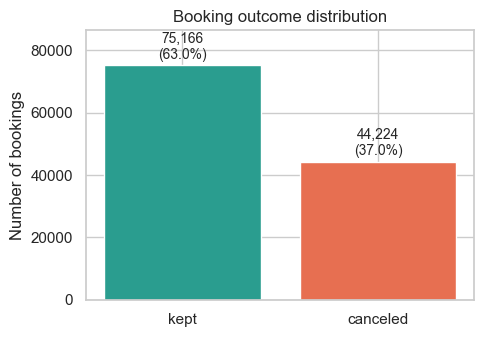

In [5]:
# Count kept vs canceled bookings, in both raw counts and percentages.
counts = df['is_canceled'].value_counts()
pct = df['is_canceled'].value_counts(normalize=True).mul(100).round(2)
print(pd.DataFrame({'count': counts, 'percent': pct}))

# Bar chart of the class split, annotated with count and share per bar.
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(['kept', 'canceled'], [counts.get(0, 0), counts.get(1, 0)],
       color=['#2a9d8f', '#e76f51'])
for i, v in enumerate([counts.get(0, 0), counts.get(1, 0)]):
    ax.text(i, v + len(df) * 0.01, f'{v:,}\n({v/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set_title('Booking outcome distribution')
ax.set_ylabel('Number of bookings')
ax.set_ylim(0, max(counts) * 1.15)
plt.savefig(IMAGES / 'target_distribution.png')
plt.show()

## 4. Data cleaning

### 4.1 Duplicate rows
Many bookings share identical attributes. In this industry that is normal: a tour operator booking a block of identical rooms produces many identical records. These are real transactions, so we keep them and only report the count.

In [6]:
# Count fully identical rows. We report but do NOT drop them - in hotel
# data, identical rows are usually real repeated bookings (group blocks).
n_dup = df.duplicated().sum()
print(f'Exactly-duplicate rows: {n_dup:,} ({n_dup/len(df)*100:.1f}% of data) - kept as real bookings')

Exactly-duplicate rows: 31,994 (26.8% of data) - kept as real bookings

### 4.2 Missing values
`company` is missing in 94% of rows (most bookings are not tied to a corporate account). `agent` is missing in 14%. `country` and `children` have only small gaps.

          missing  percent
company    112593    94.31
agent       16340    13.69
country       488     0.41
children        4     0.00

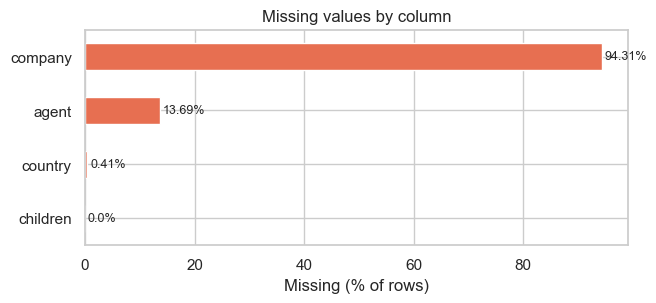

In [7]:
# Tally missing values per column, keep only columns that have any,
# and express them as a percentage of all rows.
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(2)
print(pd.DataFrame({'missing': miss, 'percent': miss_pct}))

fig, ax = plt.subplots(figsize=(7, 2.8))
miss_pct.plot(kind='barh', color='#e76f51', ax=ax)
ax.set_title('Missing values by column')
ax.set_xlabel('Missing (% of rows)')
ax.invert_yaxis()
for i, v in enumerate(miss_pct):
    ax.text(v + 0.5, i, f'{v}%', va='center', fontsize=9)
plt.savefig(IMAGES / 'missing_values.png')
plt.show()

**How we handle each gap:**

- `company`: dropped. With 94% missing it carries little usable signal, and corporate bookings can still be spotted through `customer_type`.
- `agent`: missing means "no travel agent / direct booking", so we fill with the label `0` and treat it as a category.
- `country`: fill missing with `UNK` (unknown) and keep as a category.
- `children`: only 4 rows missing, filled with 0 (the most common value).

In [8]:
df = df.drop(columns=['company'])                       # 94% missing - drop entirely
df['agent'] = df['agent'].fillna(0).astype(int).astype(str)  # missing -> '0' = direct booking
df['country'] = df['country'].fillna('UNK')             # missing -> its own 'unknown' category
df['children'] = df['children'].fillna(0).astype(int)   # 4 gaps -> 0, then store as integer
print('Remaining missing values:', int(df.isna().sum().sum()))

Remaining missing values: 0


### 4.3 Impossible and erroneous values
- 180 bookings list zero guests (no adults, children, or babies). A room cannot be occupied by nobody, so these are data-entry errors and are dropped.
- One booking has a negative average daily rate (`adr`); dropped.
- The dataset documentation flags an `adr` near 5,400 EUR as an error. We cap `adr` at its 99.9th percentile to tame that extreme tail without throwing away rows.
- `meal = 'Undefined'` means the same as `meal = 'SC'` (self-catering) per the documentation, so we merge them.

In [9]:
# Drop bookings with no guests at all - a room cannot be occupied by nobody.
before = len(df)
df = df.loc[(df['adults'] + df['children'] + df['babies']) > 0].copy()
print(f'Dropped {before - len(df)} zero-guest bookings.')

# Drop the single booking with a negative nightly rate.
before = len(df)
df = df.loc[df['adr'] >= 0].copy()
print(f'Dropped {before - len(df)} negative-adr booking(s).')

# Cap the extreme adr tail at the 99.9th percentile instead of deleting rows,
# so one data-entry error near 5,400 EUR cannot distort scaling later.
cap = df['adr'].quantile(0.999)
n_cap = int((df['adr'] > cap).sum())
df['adr'] = df['adr'].clip(upper=cap)
print(f'Capped {n_cap} booking(s) above adr = {cap:.0f} EUR (99.9th pct).')

# 'Undefined' and 'SC' are the same meal plan per the docs - merge them.
df['meal'] = df['meal'].replace({'Undefined': 'SC'})
print('Shape after cleaning:', df.shape)

Dropped 180 zero-guest bookings.
Dropped 1 negative-adr booking(s).
Capped 120 booking(s) above adr = 326 EUR (99.9th pct).
Shape after cleaning: (119209, 31)


## 5. Feature engineering

### 5.1 Leakage check - exclude outcome columns

`reservation_status` records the final state of the booking (Check-Out, Canceled, or No-Show) and `reservation_status_date` is the date that state was set. Both are only known *after* the outcome, so using them would let the model cheat. The crosstab below shows the perfect mapping. We keep them out of the model feature list (defined in notebook 2) and drop `reservation_status_date` now.

In [10]:
# Cross-tabulate the outcome-status column against the target. A perfect
# mapping here is the tell-tale sign of leakage (the column encodes the answer).
print(pd.crosstab(df['reservation_status'], df['is_canceled']))
print('\nCheck-Out always maps to kept; Canceled and No-Show always map to canceled.')
print('These columns are leakage and will NOT be used as model inputs.')

is_canceled             0      1
reservation_status              
Canceled                0  42993
Check-Out           75010      0
No-Show                 0   1206



Check-Out always maps to kept; Canceled and No-Show always map to canceled.
These columns are leakage and will NOT be used as model inputs.


### 5.2 Derived features
A handful of engineered fields that are all known at booking time:

- `total_nights` = weekend + week nights
- `total_guests` = adults + children + babies
- `is_family` = 1 if any children or babies
- `room_assigned_as_reserved` = 1 if the assigned room type matches the reserved one
- `arrival_month_num` and a parsed `arrival_date` for time trends

In [11]:
# Combine the two night-count columns and the three guest-count columns.
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests'] = df['adults'] + df['children'] + df['babies']
# Flag family bookings and bookings where the guest got a different room than reserved.
df['is_family'] = ((df['children'] > 0) | (df['babies'] > 0)).astype(int)
df['room_assigned_as_reserved'] = (df['reserved_room_type'] == df['assigned_room_type']).astype(int)

# Turn the month name into a number (1-12) so it can be used numerically...
month_map = {m: i for i, m in enumerate(
    ['January', 'February', 'March', 'April', 'May', 'June',
     'July', 'August', 'September', 'October', 'November', 'December'], 1)}
df['arrival_month_num'] = df['arrival_date_month'].map(month_map)
# ...and assemble a real arrival date for the monthly time-trend plot.
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_month_num'].astype(str) + '-' +
    df['arrival_date_day_of_month'].astype(str), errors='coerce')
df[['total_nights', 'total_guests', 'is_family', 'room_assigned_as_reserved']].describe().round(2)

,total_nights,total_guests,is_family,room_assigned_as_reserved
count,119209.00,119209.00,119209.00,119209.00
mean,3.43,1.97,0.08,0.88
std,2.54,0.72,0.27,0.33
min,0.00,1.00,0.00,0.00
25%,2.00,2.00,0.00,1.00
50%,3.00,2.00,0.00,1.00
75%,4.00,2.00,0.00,1.00
max,69.00,55.00,1.00,1.00


### 5.3 Bucket high-cardinality categories
`country` has 177 values and `agent` has hundreds. We keep the 15 most common of each and lump the rest into `OTHER`, so one-hot encoding in the modeling notebook stays manageable.

In [12]:
# Keep the 15 most frequent values of each high-cardinality column and
# relabel everything else as 'OTHER'. .where() keeps values that match the
# top list and replaces the rest, which collapses the long tail of rare codes.
TOP_K = 15
top_c = df['country'].value_counts().head(TOP_K).index
df['country_bucket'] = df['country'].where(df['country'].isin(top_c), 'OTHER')
top_a = df['agent'].value_counts().head(TOP_K).index
df['agent_bucket'] = df['agent'].where(df['agent'].isin(top_a), 'OTHER')
print(f'country_bucket categories: {df["country_bucket"].nunique()}')
print(f'agent_bucket categories:   {df["agent_bucket"].nunique()}')

country_bucket categories: 16
agent_bucket categories:   16


## 6. Outlier analysis
We look at the heavy-tailed numeric fields. The tails here are real behavior (corporate blocks booked far ahead, repeat cancellers), so we keep them and rely on scaling in the model rather than deleting rows.

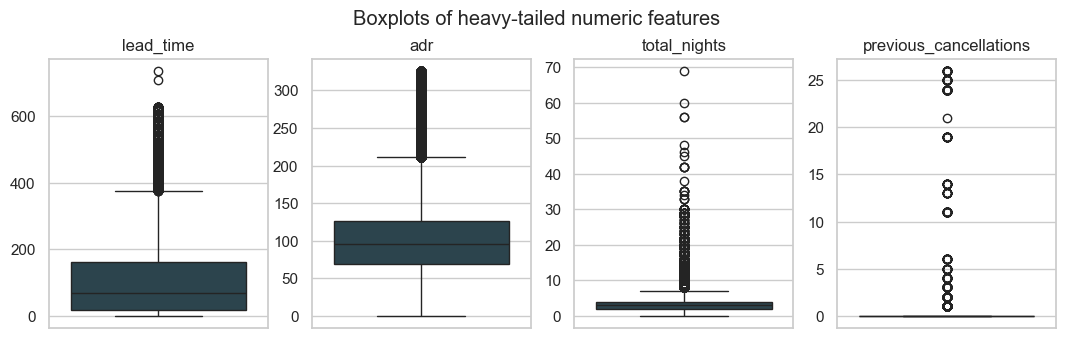

In [13]:
ocols = ['lead_time', 'adr', 'total_nights', 'previous_cancellations']
fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
for ax, c in zip(axes, ocols):
    sns.boxplot(y=df[c], ax=ax, color='#264653')
    ax.set_title(c); ax.set_ylabel('')
fig.suptitle('Boxplots of heavy-tailed numeric features', y=1.02)
plt.savefig(IMAGES / 'outliers_boxplots.png')
plt.show()

In [14]:
# Quantify outliers with the standard 1.5 x IQR rule: anything beyond
# 1.5 interquartile ranges past Q1/Q3 is flagged. We count them rather
# than remove them, to decide whether the tails are worth keeping.
def iqr_report(s):
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = int(((s < lo) | (s > hi)).sum())
    return {'q1': q1, 'q3': q3, 'upper_fence': round(hi, 1),
            'n_outliers': n, 'pct': round(n / len(s) * 100, 2)}
print(pd.DataFrame({c: iqr_report(df[c]) for c in ocols}).T)

                          q1     q3  upper_fence  n_outliers   pct
lead_time               18.0  161.0        375.5      2981.0  2.50
adr                     69.5  126.0        210.8      3864.0  3.24
total_nights             2.0    4.0          7.0      5225.0  4.38
previous_cancellations   0.0    0.0          0.0      6479.0  5.43


## 7. Univariate exploration

### 7.1 Numeric features

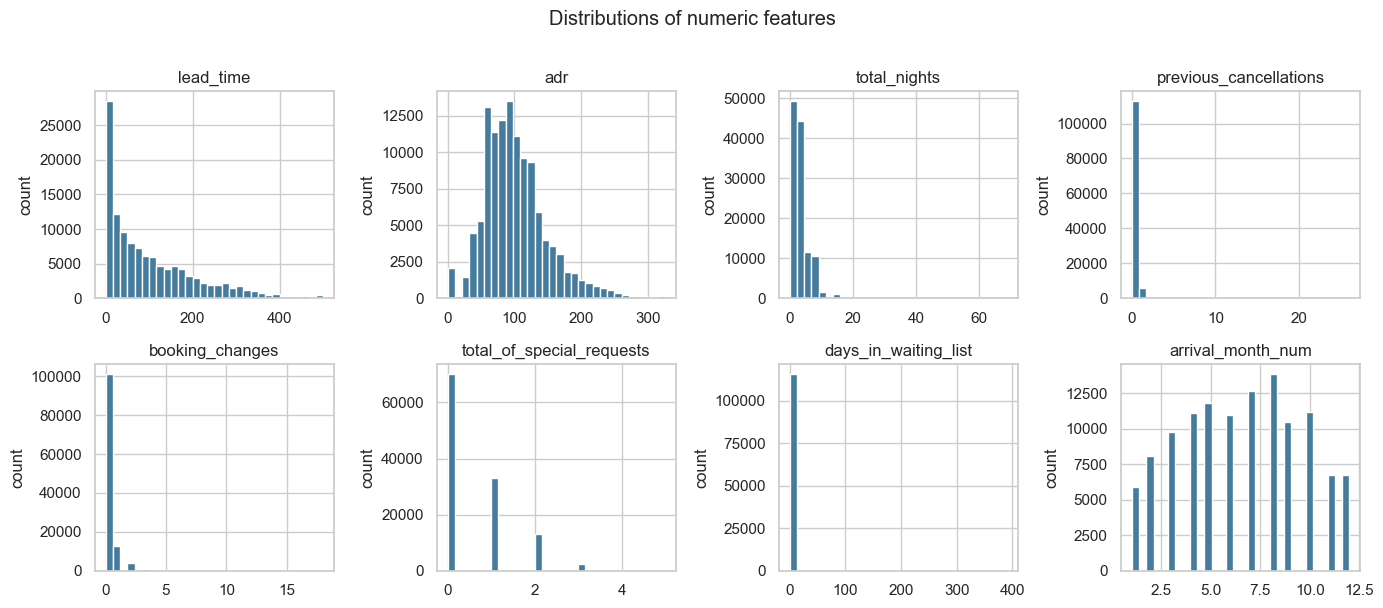

In [15]:
ncols = ['lead_time', 'adr', 'total_nights', 'previous_cancellations',
         'booking_changes', 'total_of_special_requests',
         'days_in_waiting_list', 'arrival_month_num']
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, c in zip(axes.flat, ncols):
    # Clip the very long lead_time tail at 500 days so the histogram stays readable.
    s = df[c].clip(upper=500) if c == 'lead_time' else df[c]
    ax.hist(s, bins=30, color='#457b9d', edgecolor='white')
    ax.set_title(c); ax.set_ylabel('count')
fig.suptitle('Distributions of numeric features', y=1.01)
plt.tight_layout()
plt.savefig(IMAGES / 'numeric_histograms.png')
plt.show()

### 7.2 Categorical features

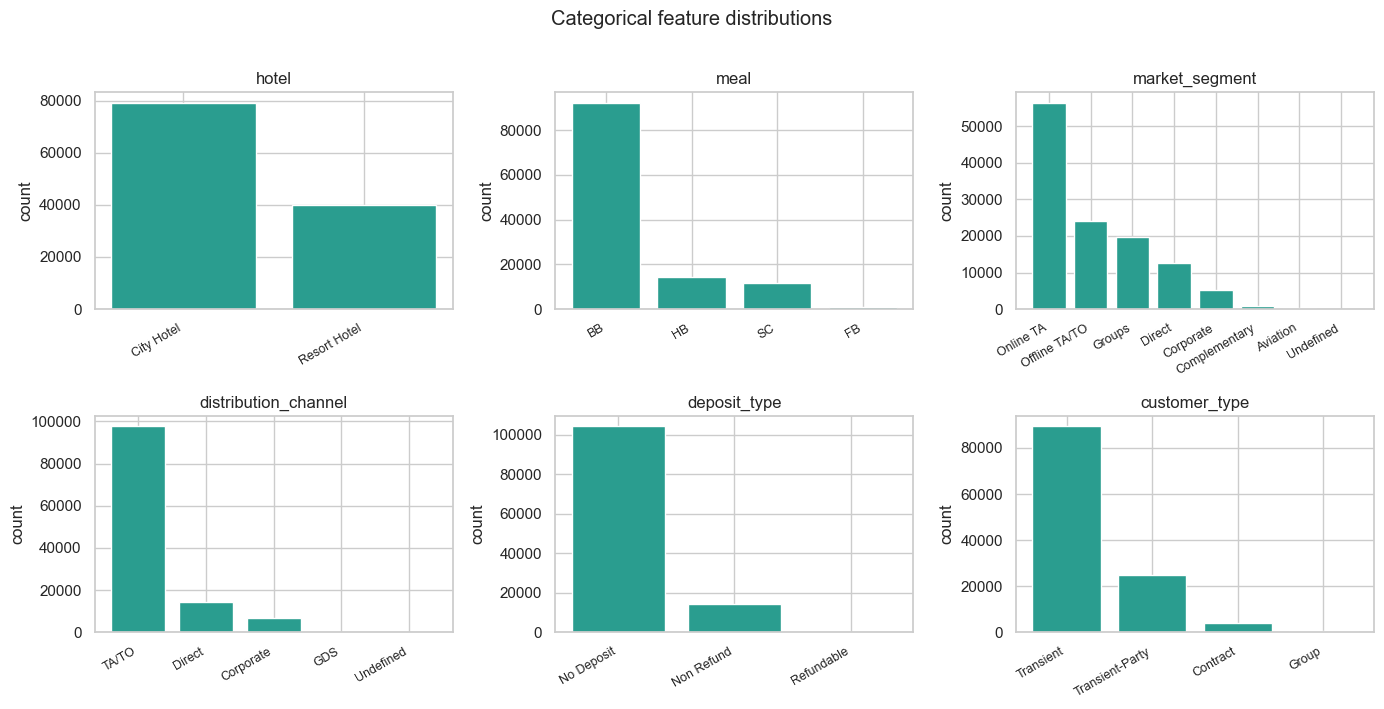

In [16]:
ccols = ['hotel', 'meal', 'market_segment',
         'distribution_channel', 'deposit_type', 'customer_type']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, c in zip(axes.flat, ccols):
    vc = df[c].value_counts()
    ax.bar(range(len(vc)), vc.values, color='#2a9d8f')
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(c); ax.set_ylabel('count')
fig.suptitle('Categorical feature distributions', y=1.01)
plt.tight_layout()
plt.savefig(IMAGES / 'categorical_distributions.png')
plt.show()

## 8. Relationship to cancellation

### 8.1 Cancellation rate by category
The dashed line is the overall 37% base rate; bars above it cancel more than average.

Overall cancellation rate: 37.08%


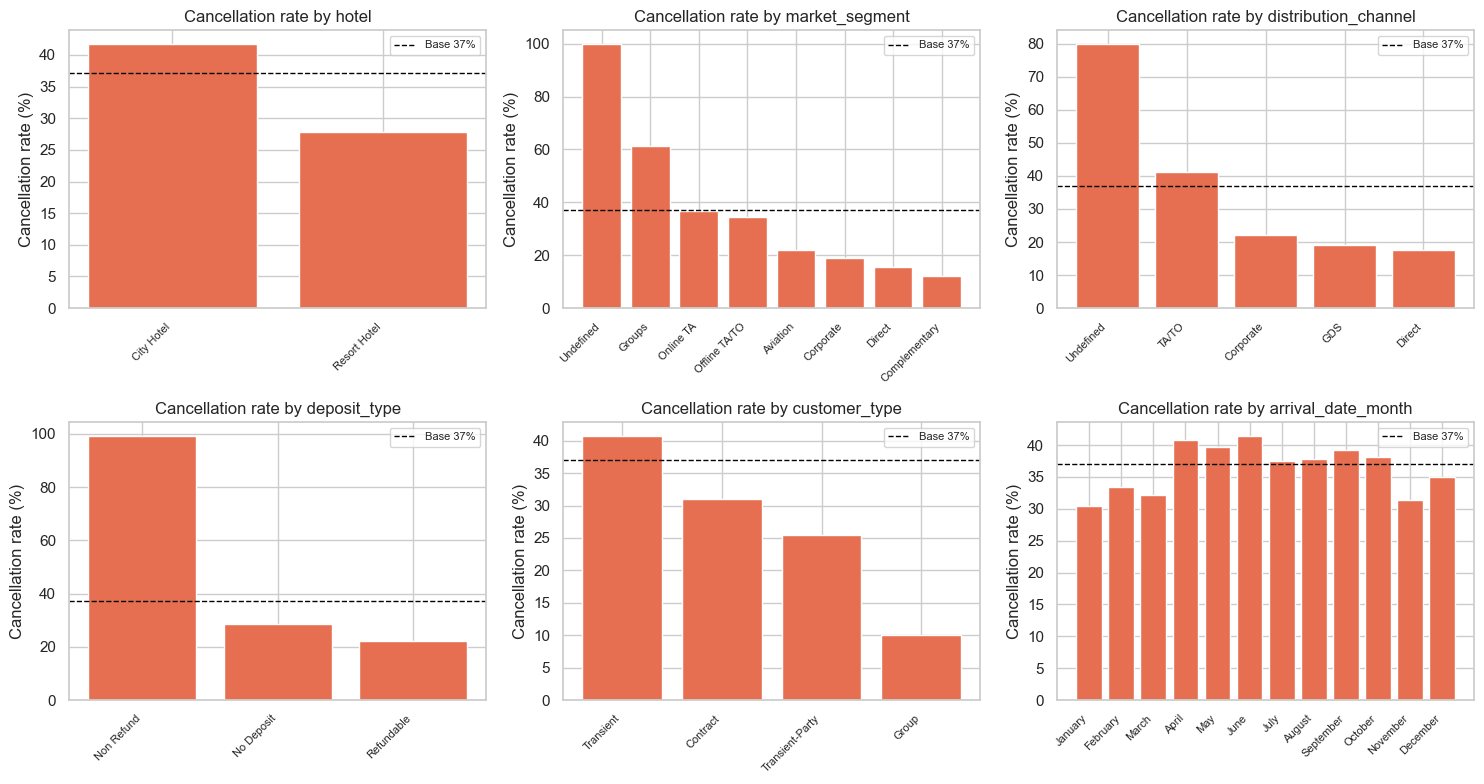

In [17]:
# Because is_canceled is 0/1, its mean within a group IS that group's
# cancellation rate. BASE is the overall rate used as a reference line.
BASE = df['is_canceled'].mean()
print(f'Overall cancellation rate: {BASE*100:.2f}%')
rate_cols = ['hotel', 'market_segment', 'distribution_channel',
             'deposit_type', 'customer_type', 'arrival_date_month']
morder = ['January', 'February', 'March', 'April', 'May', 'June',
          'July', 'August', 'September', 'October', 'November', 'December']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.flat, rate_cols):
    # Mean of the 0/1 target per category = cancellation rate for that category.
    r = df.groupby(c, observed=True)['is_canceled'].mean()
    r = r.reindex(morder) if c == 'arrival_date_month' else r.sort_values(ascending=False)
    ax.bar(range(len(r)), r.values * 100, color='#e76f51')
    ax.axhline(BASE * 100, color='black', ls='--', lw=1, label=f'Base {BASE*100:.0f}%')
    ax.set_xticks(range(len(r)))
    ax.set_xticklabels(r.index, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'Cancellation rate by {c}')
    ax.set_ylabel('Cancellation rate (%)')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(IMAGES / 'cancellation_rate_by_category.png')
plt.show()

### 8.2 Numeric features split by outcome

C:\Users\aeh12\AppData\Local\Temp\ipykernel_77568\4256510814.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['kept', 'canceled']); ax.set_xlabel(''); ax.set_title(c)
C:\Users\aeh12\AppData\Local\Temp\ipykernel_77568\4256510814.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['kept', 'canceled']); ax.set_xlabel(''); ax.set_title(c)
C:\Users\aeh12\AppData\Local\Temp\ipykernel_77568\4256510814.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['kept', 'canceled']); ax.set_xlabel(''); ax.set_title(c)
C:\Users\aeh12\AppData\Local\Temp\ipykernel_77568\4256510814.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using

C:\Users\aeh12\AppData\Local\Temp\ipykernel_77568\4256510814.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['kept', 'canceled']); ax.set_xlabel(''); ax.set_title(c)
C:\Users\aeh12\AppData\Local\Temp\ipykernel_77568\4256510814.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['kept', 'canceled']); ax.set_xlabel(''); ax.set_title(c)


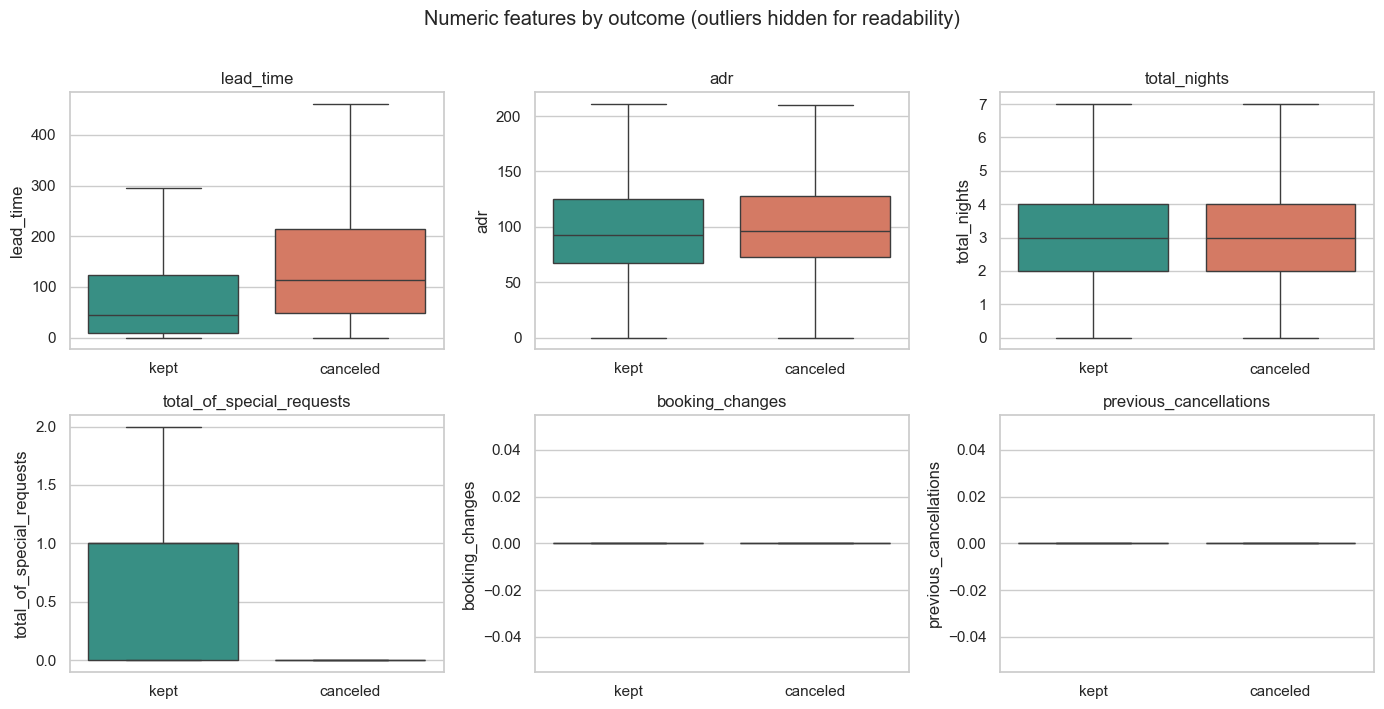

In [18]:
scols = ['lead_time', 'adr', 'total_nights',
         'total_of_special_requests', 'booking_changes', 'previous_cancellations']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, c in zip(axes.flat, scols):
    sns.boxplot(x='is_canceled', y=c, data=df, order=[0, 1],
                palette=['#2a9d8f', '#e76f51'], ax=ax, showfliers=False)
    ax.set_xticklabels(['kept', 'canceled']); ax.set_xlabel(''); ax.set_title(c)
fig.suptitle('Numeric features by outcome (outliers hidden for readability)', y=1.01)
plt.tight_layout()
plt.savefig(IMAGES / 'numeric_by_target.png')
plt.show()

### 8.3 The deposit-type surprise
Intuition says a non-refundable deposit should make people *less* likely to cancel. The data shows the opposite, and dramatically so. We flag this clearly for the business; it likely reflects how the booking system records voided reservations rather than guest behavior.

              bookings  cancel_rate
deposit_type                       
No Deposit      104460         28.4
Non Refund       14587         99.4
Refundable         162         22.2


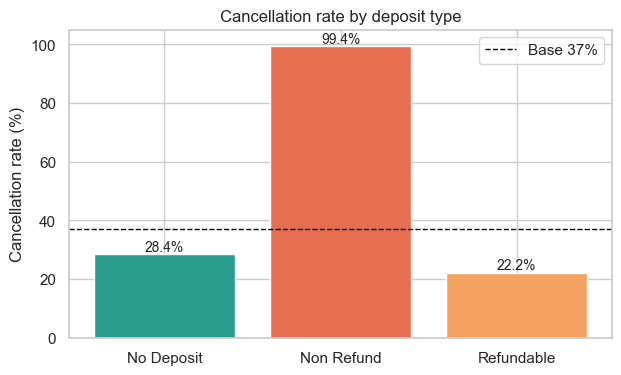

In [19]:
dv = (df.groupby('deposit_type', observed=True)
        .agg(bookings=('is_canceled', 'size'), cancel_rate=('is_canceled', 'mean')))
dv['cancel_rate'] = (dv['cancel_rate'] * 100).round(1)
print(dv.sort_values('bookings', ascending=False))

fig, ax = plt.subplots(figsize=(7, 4))
order = dv.sort_values('bookings', ascending=False)
ax.bar(order.index, order['cancel_rate'], color=['#2a9d8f', '#e76f51', '#f4a261'])
ax.axhline(BASE * 100, color='black', ls='--', lw=1, label=f'Base {BASE*100:.0f}%')
for i, v in enumerate(order['cancel_rate']):
    ax.text(i, v + 1, f'{v}%', ha='center', fontsize=10)
ax.set_title('Cancellation rate by deposit type')
ax.set_ylabel('Cancellation rate (%)'); ax.set_ylim(0, 105); ax.legend()
plt.savefig(IMAGES / 'deposit_type_paradox.png')
plt.show()

### 8.4 Lead time - the strongest single driver

             bookings  cancel_rate
lead_bucket                       
0-7d            19635         9.60
8-30d           18945        27.89
31-90d          29529        37.73
91-180d         26420        44.74
181-365d        21533        55.46
365d+            3147        67.65


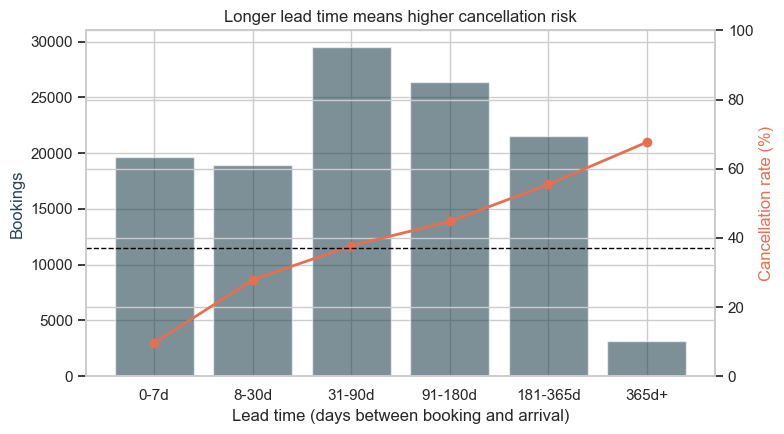

In [20]:
# Bin the continuous lead_time into readable ranges, then measure the
# cancellation rate within each bin to expose the trend cleanly.
df['lead_bucket'] = pd.cut(df['lead_time'],
    bins=[-1, 7, 30, 90, 180, 365, 1000],
    labels=['0-7d', '8-30d', '31-90d', '91-180d', '181-365d', '365d+'])
lv = (df.groupby('lead_bucket', observed=True)
        .agg(bookings=('is_canceled', 'size'), cancel_rate=('is_canceled', 'mean')))
lv['cancel_rate'] *= 100
print(lv.round(2))

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.bar(lv.index.astype(str), lv['bookings'], color='#264653', alpha=.6)
ax1.set_ylabel('Bookings', color='#264653')
ax1.set_xlabel('Lead time (days between booking and arrival)')
ax2 = ax1.twinx()
ax2.plot(lv.index.astype(str), lv['cancel_rate'], color='#e76f51', marker='o', lw=2)
ax2.axhline(BASE * 100, color='black', ls='--', lw=1)
ax2.set_ylabel('Cancellation rate (%)', color='#e76f51'); ax2.set_ylim(0, 100)
ax1.set_title('Longer lead time means higher cancellation risk')
plt.tight_layout()
plt.savefig(IMAGES / 'lead_time_effect.png')
plt.show()

### 8.5 Cancellation rate over time

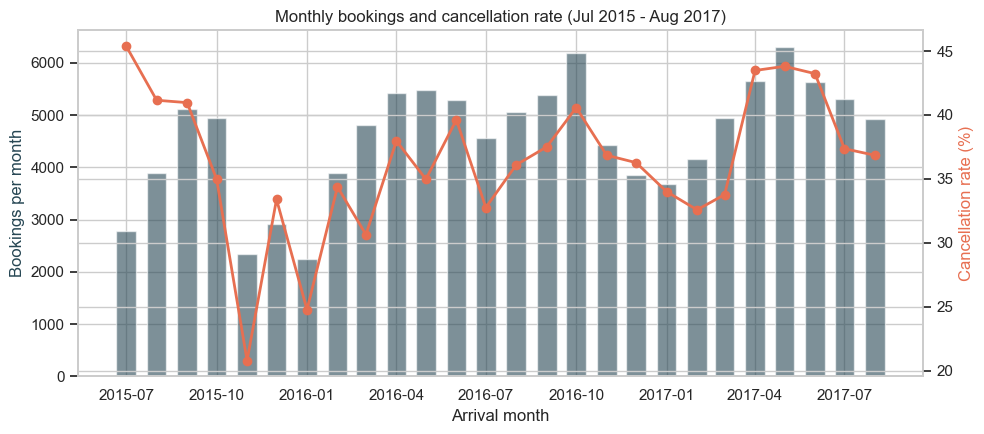

In [21]:
# Resample by month start ('MS') to get bookings and cancellation rate per
# calendar month, so seasonality and any drift over time become visible.
monthly = (df.set_index('arrival_date').resample('MS')['is_canceled']
             .agg(['size', 'mean']).rename(columns={'size': 'bookings', 'mean': 'rate'}))
monthly['rate'] *= 100
fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.bar(monthly.index, monthly['bookings'], width=20, color='#264653', alpha=.6)
ax1.set_ylabel('Bookings per month', color='#264653')
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['rate'], color='#e76f51', marker='o', lw=2)
ax2.set_ylabel('Cancellation rate (%)', color='#e76f51')
ax1.set_title('Monthly bookings and cancellation rate (Jul 2015 - Aug 2017)')
ax1.set_xlabel('Arrival month')
plt.tight_layout()
plt.savefig(IMAGES / 'time_trend.png')
plt.show()

### 8.6 Correlation among numeric features

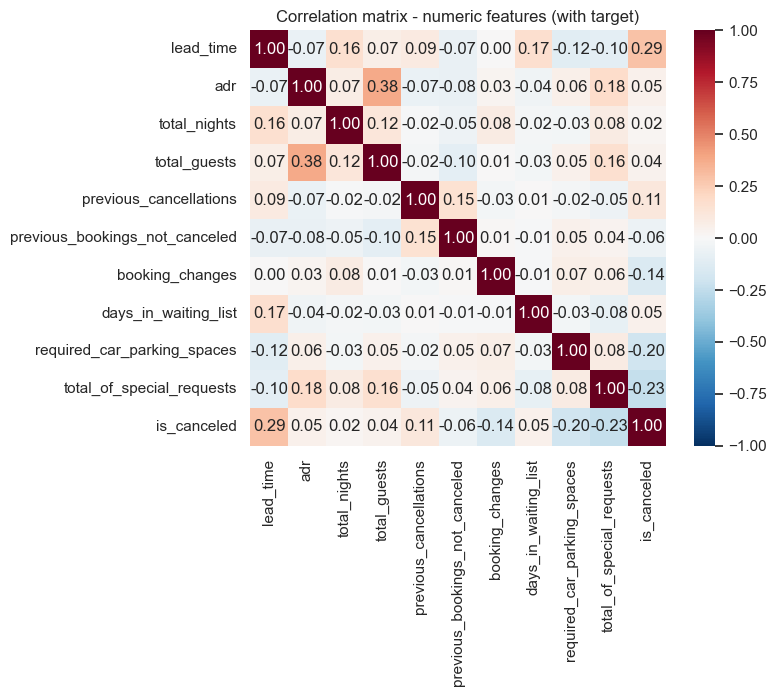

In [22]:
corr_cols = ['lead_time', 'adr', 'total_nights', 'total_guests',
             'previous_cancellations', 'previous_bookings_not_canceled',
             'booking_changes', 'days_in_waiting_list',
             'required_car_parking_spaces', 'total_of_special_requests', 'is_canceled']
# Pearson correlation between numeric features (target included) to spot
# redundant pairs and any linear signal toward cancellation.
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Correlation matrix - numeric features (with target)')
plt.tight_layout()
plt.savefig(IMAGES / 'correlation_heatmap.png')
plt.show()

## 9. Inferential statistics

The charts above are descriptive. Here we test whether the patterns are statistically significant rather than noise. With ~119k rows even tiny differences will be "significant", so we also report an effect size (Cramer's V for the categorical tests) to judge whether a relationship is large enough to matter in practice.

### 9.1 Chi-square tests of independence (categorical vs cancellation)

In [23]:
# Cramer's V rescales the chi-square statistic to a 0-1 effect size, so we
# can compare the STRENGTH of association across features (not just whether
# it is significant, which is almost guaranteed at this sample size).
def cramers_v(confusion):
    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.to_numpy().sum()
    r, k = confusion.shape
    return np.sqrt((chi2 / n) / (min(r, k) - 1))

# For each categorical feature: build a contingency table vs the target,
# run the chi-square test of independence, and record p-value + effect size.
rows = []
for col in ['deposit_type', 'hotel', 'customer_type', 'market_segment',
            'distribution_channel', 'is_repeated_guest']:
    ct = pd.crosstab(df[col], df['is_canceled'])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    rows.append({'feature': col, 'chi2': round(chi2, 1),
                 'p_value': f'{p:.2e}', 'cramers_v': round(cramers_v(ct), 3)})
chi_results = pd.DataFrame(rows).sort_values('cramers_v', ascending=False)
print(chi_results.to_string(index=False))

             feature    chi2   p_value  cramers_v
        deposit_type 27641.1  0.00e+00      0.482
      market_segment  8499.7  0.00e+00      0.267
distribution_channel  3741.3  0.00e+00      0.177
               hotel  2239.3  0.00e+00      0.137
       customer_type  2224.7  0.00e+00      0.137
   is_repeated_guest   834.6 1.65e-183      0.084


Every categorical feature is significantly associated with cancellation (all p-values far below 0.05). By effect size, `deposit_type` has by far the strongest association, followed by `market_segment` and `distribution_channel`. `is_repeated_guest` is significant but weak.

### 9.2 Group comparison for lead time
Lead time is heavily right-skewed, so we use the non-parametric Mann-Whitney U test (which compares distributions without assuming normality) and report the rank-biserial correlation as the effect size.

In [24]:
# Split lead_time by outcome and test whether canceled bookings are made
# further ahead. Mann-Whitney U is used because lead_time is far from normal;
# rank-biserial converts the U statistic into a 0-1 effect size.
canc = df.loc[df['is_canceled'] == 1, 'lead_time']
kept = df.loc[df['is_canceled'] == 0, 'lead_time']
u, p = stats.mannwhitneyu(canc, kept, alternative='greater')
rank_biserial = 1 - (2 * u) / (len(canc) * len(kept))
print(f'Median lead time  - canceled: {canc.median():.0f} days,  kept: {kept.median():.0f} days')
print(f'Mann-Whitney U = {u:,.0f},  p-value = {p:.2e}')
print(f'Rank-biserial effect size = {abs(rank_biserial):.3f}')
print('\nCanceled bookings are made significantly further in advance than kept bookings.')

Median lead time  - canceled: 113 days,  kept: 45 days
Mann-Whitney U = 2,284,666,098,  p-value = 0.00e+00
Rank-biserial effect size = 0.378

Canceled bookings are made significantly further in advance than kept bookings.


## 10. Save the cleaned dataset
The modeling notebook reads this file so it does not have to repeat the cleaning and feature-engineering steps.

In [25]:
clean_path = DATA / 'hotel_bookings_clean.csv'
df.to_csv(clean_path, index=False)
print(f'Saved cleaned dataset: {clean_path.name}  ({df.shape[0]:,} rows x {df.shape[1]} cols)')

Saved cleaned dataset: hotel_bookings_clean.csv  (119,209 rows x 40 cols)


## 11. EDA summary

- The dataset is large (~119k bookings) and reasonably clean after removing 181 impossible rows, dropping the mostly-empty `company` column, and filling small gaps in `agent`, `country`, and `children`.
- About 37% of bookings cancel, so the problem is moderately imbalanced and accuracy alone is not a trustworthy metric.
- `reservation_status` and `reservation_status_date` are outcome leakage and are excluded from modeling.
- **Lead time** is the single strongest driver: bookings made more than six months ahead cancel over five times as often as last-minute ones.
- **Deposit type** has the strongest categorical association, but in a counter-intuitive direction (non-refundable bookings almost always cancel in this data) - flagged for the business to investigate.
- Inferential tests confirm these relationships are statistically significant with meaningful effect sizes, not artifacts of the large sample.

Next: `2_modeling_and_evaluation.ipynb` trains and tunes several classifiers on this cleaned dataset and recommends one for use.